## 用卷积神经网络（converlutional Neural Network）进行表情识别

在这个Notebook中，我们将学习如何使用MindSpore框架来构建简单的卷积神经网络，以及使用该网络对自己采集的表情数据集进行识别。
包括以下几个步骤：
1. 数据集准备
2. 构建卷积神经网络
3. 训练模型
4. 保存模型并结合opencv人脸检测模型进行表情识别

In [ ]:
# 上华为云端运行时，才运行此cell的代码

# 主要作用是取消`RANK_TABLE_FILE`环境变量，否则会以静态图O2模式运行

import os
original_rank_table = os.environ.get('RANK_TABLE_FILE')
os.environ.pop('RANK_TABLE_FILE', None)

In [2]:
import os
import sys
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import mindspore
from mindspore.dataset import GeneratorDataset, transforms, vision
from mindspore import nn, ops, mint
from mindspore import save_checkpoint
from mindspore import load_checkpoint, load_param_into_net

Matplotlib is building the font cache; this may take a moment.


In [3]:
# 上华为云进行NPU加速时，运行此代码
# mindspore.set_device("Ascend",0)

# 本地使用
mindspore.set_device("CPU")

### 创建自己的DATASET类

如何基于昇思MindSpore构建自定义数据集可参考如下教程：[数据加载与处理](https://www.mindspore.cn/tutorials/zh-CN/r2.6.0/beginner/dataset.html#%E5%8F%AF%E9%9A%8F%E6%9C%BA%E8%AE%BF%E9%97%AE%E6%95%B0%E6%8D%AE%E9%9B%86)

In [4]:
import os
from PIL import Image
class MyDataset:
    """自定义数据集"""
    def __init__(self, images_path: list, images_class: list):
        self.images_path = images_path
        self.images_class = images_class

    def __len__(self):
        return len(self.images_path)

    def __getitem__(self, item):
        img_path = self.images_path[item]
        label = self.images_class[item]
        try:
            # 打开图片
            img = Image.open(img_path)
            
            # 检查图片模式，如果不是RGB，则转换为RGB
            if img.mode != 'RGB':
                img = img.convert('RGB')
            
            # 返回处理好的图片和标签
            return img, label
            
        except Exception as e:
            # 如果在处理过程中发生任何错误（如文件损坏）
            # 打印出出错的文件路径和具体错误信息
            print(f"处理图片时出错: {img_path}")
            print(f"错误信息: {e}")
            # 重新抛出异常，这一点对于调试非常重要
            raise e

In [5]:
def create_dataset(root):  #这里的root是数据集根目录的路径，注意分类数据集的数据存放形式
    all_class = [cla for cla in os.listdir(root) if os.path.isdir(os.path.join(root, cla))]  #读取所有类别
    all_class.sort()
    class_indices = dict((k, v) for v, k in enumerate(all_class)) # 为每个类别分配一个数字
    images_path = []
    images_label = []
    for cla in all_class:
        cla_path = os.path.join(root, cla)
        # 修改后的代码
        images = [os.path.join(root, cla, i) for i in os.listdir(cla_path) if i.endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        #读取所有图片的完整相对路径
        image_class = class_indices[cla] #获取label
        for image_path in images:
            images_path.append(image_path)
            images_label.append(image_class)
        

    return images_path, images_label

In [9]:
#root = "/home/ma-user/work"   #华为云上的默认路径

root = "./face_dataset"
train_images_path, train_images_label = create_dataset(os.path.join(root, 'train'))
val_images_path, val_images_label = create_dataset(os.path.join(root, 'val')) 

# 自定义Python数据源
train_dataset_loader = MyDataset(train_images_path, train_images_label)
val_dataset_lodaer = MyDataset(val_images_path, val_images_label)

In [10]:
batch_size = 32
# 通过迭代自定义Python数据源构造数据集
train_dataset = GeneratorDataset(train_dataset_loader, column_names=["image", "label"], shuffle=True)
val_dataset = GeneratorDataset(val_dataset_lodaer, column_names=["image", "label"], shuffle=False)

遍历数据集，检验图片是否加载成功。

In [11]:
for image, label in train_dataset.create_tuple_iterator():
    pass

In [12]:
for image, label in val_dataset.create_tuple_iterator():
    pass

### 定义数据处理Pipeline

自定义数据加载和批处理的方式，基于MindSpore的数据增强可参考：[数据变换](https://www.mindspore.cn/tutorials/zh-CN/r2.6.0/beginner/dataset.html#%E6%95%B0%E6%8D%AE%E5%8F%98%E6%8D%A2)

In [13]:
def datapipe(dataset, batch_size):
    image_transforms = [
        transforms.TypeCast(mindspore.float32), 
        vision.Rescale(1.0 / 255.0, 0.0),
        vision.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, .224, 0.225]),
        vision.HWC2CHW()
    ]
    label_transform = transforms.TypeCast(mindspore.int32)
    
    dataset = dataset.map(image_transforms, 'image')
    dataset = dataset.map(label_transform, 'label')
    dataset = dataset.batch(batch_size)
    return dataset

In [14]:
processed_train_dataset = datapipe(train_dataset, batch_size)
processed_val_dataset = datapipe(val_dataset, batch_size)

迭代数据集，查看图像和标签数据的形状和数据类型。

In [15]:
data_iter = next(processed_val_dataset.create_dict_iterator())

images = data_iter['image'].asnumpy()
labels = data_iter['label'].asnumpy()
print(f"Image shape: {images.shape}, Label shape: {labels.shape}")
print(f"Image dtype: {images.dtype}, Label dtype: {labels.dtype}")

Image shape: (32, 3, 320, 240), Label shape: (32,)
Image dtype: float32, Label dtype: int32


数据可视化

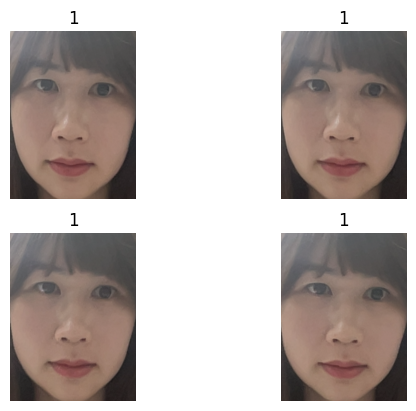

In [16]:
classes = ["1", "2", "3"]

plt.figure()
for i in range(4):
    plt.subplot(2, 2, i + 1)
    image_test = np.transpose(images[i], (1, 2, 0))
    # matplotlib 的 imshow 函数需要 (高, 宽, 通道) 即 (H, W, C) 的格式。
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1993, 0.2010])
    image_test = std * image_test + mean
    image_test = np.clip(image_test, 0, 1)
    plt.title(f"{classes[labels[i]]}")
    plt.imshow(image_test)
    plt.axis("off")
plt.show()

#### MindSpore搭建卷积神经网络模型

首先搭建一个六层的卷积神经网络，4层卷积层，2层全连接。

输入为(240,320)彩色图，第一个层卷积层一个kernel/filter 的shape是3x3，共32个kernel/filter组成，relu函数作为激活函数，有padding。

接一个2x2的Maxpooling层.

第二个卷积层kernel3x3，共64个kernel/filter组成，relu函数作为激活函数，padding。

接一个2x2的Maxpooling层.

第三个卷积层kernel 3x3，共128个kernel/filter组成，relu函数作为激活函数，padding。

接一个2x2的Maxpooling层.

第四个卷积层kernel 3x3，共256个kernel/filter组成，relu函数作为激活函数，padding。

接一个2x2的Maxpooling层.


然后拉成一维，再跟100个神经元做一个全连接，relu函数作为激活函数。

最后，输出层3个神经元（多分类问题），softmax作为激活函数。

In [17]:
def conv_block(in_channels, out_channels, pool_kernel, pool_stride):
    """构建一个卷积块：卷积 -> BN -> ReLU -> 池化"""
    return nn.SequentialCell(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, pad_mode='pad', padding=1, has_bias=True),
        nn.BatchNorm2d(out_channels, momentum=0.1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=pool_kernel, stride=pool_stride)
    )

class CNN(nn.Cell):
    def __init__(self):
        super().__init__()
        self.features = nn.SequentialCell(
            conv_block(3, 32, pool_kernel=2, pool_stride=2),
            conv_block(32, 64, pool_kernel=2, pool_stride=2),
            conv_block(64, 128, pool_kernel=4, pool_stride=4),
            conv_block(128, 256, pool_kernel=4, pool_stride=4)
        )
        self.classifier = nn.SequentialCell(
            nn.Dense(3840, 100),
            nn.ReLU(),
            nn.Dense(100, 3)
        )

    def construct(self, x):
        x = self.features(x)
        # 将特征图展平成一维向量

        x = x.view(x.shape[0], -1)
        
        x = self.classifier(x)
        return x
model = CNN()

In [18]:
# 打印模型结构
print(model)

CNN(
  (features): SequentialCell(
    (0): SequentialCell(
      (0): Conv2d(input_channels=3, output_channels=32, kernel_size=(3, 3), stride=(1, 1), pad_mode=pad, padding=1, dilation=(1, 1), group=1, has_bias=True, weight_init=<mindspore.common.initializer.HeUniform object at 0x000001F5762876D0>, bias_init=<mindspore.common.initializer.Uniform object at 0x000001F576287940>, format=NCHW)
      (1): BatchNorm2d(num_features=32, eps=1e-05, momentum=0.09999999999999998, gamma=Parameter (name=features.0.1.gamma, shape=(32,), dtype=Float32, requires_grad=True), beta=Parameter (name=features.0.1.beta, shape=(32,), dtype=Float32, requires_grad=True), moving_mean=Parameter (name=features.0.1.moving_mean, shape=(32,), dtype=Float32, requires_grad=False), moving_variance=Parameter (name=features.0.1.moving_variance, shape=(32,), dtype=Float32, requires_grad=False))
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, pad_mode=VALID)
    )
    (1): SequentialCell(
      (0): Conv2d(in

**想一想：你会计算params的个数吗？**

### 训练模型
我们先定义一下训练一个epoch函数和评价的函数。

In [19]:
optimizer = nn.AdamWeightDecay(model.trainable_params(), learning_rate=0.001)
loss_fn = nn.CrossEntropyLoss()

# 定义正向计算函数
def forward_fn(images, labels):
    pred = model(images)
    loss = loss_fn(pred, labels)
    return loss, pred

# 函数变换，获取微分函数
grad_fn = mindspore.value_and_grad(forward_fn, None, optimizer.parameters, has_aux=True)

# 定义一个step的训练
def train_step(images, labels):
    (loss, pred), grads = grad_fn(images, labels)
    is_finite = mint.isfinite(loss)
    if is_finite:
        optimizer(grads)
    else:
        print(f'WARNING: non-finite loss {loss}, skipping this step.')
    return loss, pred

# 训练一个epoch函数
def train(model, dataset, epoch):
    model.set_train()
    accu_loss = mint.zeros(1)  # 累计损失
    accu_num = mint.zeros(1)  # 累计预测正确的样本数
    sample_num = 0  # 累计样本数
    for step, data in enumerate(dataset.create_tuple_iterator()):
        images, labels = data
        sample_num += images.shape[0]
        loss, pred = train_step(images, labels)
        accu_loss += loss
        # print(accu_loss)
        # print(pred.shape)
        pred_classes = mint.max(pred, dim=1)[1]
        accu_num += mint.eq(pred_classes, labels).sum()
        print(accu_num)
        
        print("[train epoch {}] loss: {:.3f}, acc: {:.3f}".format(epoch, 
                                                                  accu_loss.item() / (step + 1), 
                                                                  accu_num.item() / sample_num))
        return accu_loss.item() / (step + 1), accu_num.item() / sample_num

# 评估函数
def evaluate(model, dataset, epoch):
    model.set_train(False)
    size = dataset.get_dataset_size()
    accu_loss = mint.zeros(1)  # 累计损失
    accu_num = mint.zeros(1)  # 累计预测正确的样本数
    sample_num = 0  # 累计样本数
    for step, data in enumerate(dataset.create_tuple_iterator()):
        images, labels = data
        sample_num += images.shape[0]
        pred = model(images)
        # print(pred.shape)
        pred_classes = mint.max(pred, dim=1)[1]
        accu_num += mint.eq(pred_classes, labels).sum()
        # print(accu_num)
        
        loss = loss_fn(pred, labels)
        accu_loss += loss
        # print(accu_loss)
        
        print("[valid epoch {}] loss: {:.3f}, acc: {:.3f}".format(epoch, 
                                                                  accu_loss.item() / (step + 1), 
                                                                  accu_num.item() / sample_num))
        return accu_loss.item() / (step + 1), accu_num.item() / sample_num


### 开始训练


In [20]:
epochs = 40
for epoch in range(epochs):
    # train
    train_loss, train_acc = train(model=model,
                                  dataset=processed_train_dataset,
                                  epoch=epoch)

    # validate
    val_loss, val_acc = evaluate(model=model,
                                 dataset=processed_val_dataset,
                                 epoch=epoch)
        

save_checkpoint(model, "model_best.ckpt")
        

[9.]
[train epoch 0] loss: 1.117, acc: 0.281
[valid epoch 0] loss: 11.938, acc: 0.000
[12.]
[train epoch 1] loss: 11.824, acc: 0.375
[valid epoch 1] loss: 0.000, acc: 1.000
[11.]
[train epoch 2] loss: 6.349, acc: 0.344
[valid epoch 2] loss: 0.004, acc: 1.000
[6.]
[train epoch 3] loss: 2.071, acc: 0.188
[valid epoch 3] loss: 11.938, acc: 0.000
[11.]
[train epoch 4] loss: 3.231, acc: 0.344
[valid epoch 4] loss: 13.676, acc: 0.000
[12.]
[train epoch 5] loss: 4.727, acc: 0.375
[valid epoch 5] loss: 9.291, acc: 0.000
[9.]
[train epoch 6] loss: 3.342, acc: 0.281
[valid epoch 6] loss: 2.294, acc: 0.000
[16.]
[train epoch 7] loss: 1.451, acc: 0.500
[valid epoch 7] loss: 0.040, acc: 1.000
[22.]
[train epoch 8] loss: 0.966, acc: 0.688
[valid epoch 8] loss: 0.002, acc: 1.000
[10.]
[train epoch 9] loss: 1.930, acc: 0.312
[valid epoch 9] loss: 0.006, acc: 1.000
[14.]
[train epoch 10] loss: 1.270, acc: 0.438
[valid epoch 10] loss: 0.060, acc: 1.000
[19.]
[train epoch 11] loss: 0.821, acc: 0.594
[val

### 用Opencv读取人脸检测、表情识别pt模型并推理
在OpenCV那一节当中，我们学了如何使用dnn中的推理模块读取人脸检测模型，进行人脸检测，画出人脸框。训练了我们自己的人脸表情识别模型后，我们可以将其加入，在检测好人脸之后，在人脸区域运用表情识别推理出人的表情，并显示。

In [22]:
import cv2
import numpy as np
import time

model_bin = "./models/models/face_detector/opencv_face_detector_uint8.pb"
config_text = "./models/models/face_detector/opencv_face_detector.pbtxt";

class_names = ['normal','surprise','happy']

#加载训练好的模型
net = CNN()
param_dict = mindspore.load_checkpoint("model_best.ckpt")
param_not_load, _ = mindspore.load_param_into_net(net, param_dict)
print(param_not_load)
# model.eval()


[]


In [23]:
def transform(img):
    image_transforms = [
            vision.Rescale(1.0 / 255.0, 0.0),
            vision.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, .224, 0.225]),
            vision.HWC2CHW()
    ]
    for trans in image_transforms:
        img = trans(img)
    img = mindspore.Tensor(img).expand_dims(0)
    return img

### 实时视频读取测试

In [25]:
import cv2
import numpy as np


def get_face_data_realtime(): 
    # 加载用于检测人脸的模型文件
    net_face = cv2.dnn.readNetFromTensorflow(model_bin, config=config_text)
    font = cv2.FONT_HERSHEY_SIMPLEX
    
    # 打开默认摄像头
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: Could not open video stream.")

    while True:
        # 逐帧捕获
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        h, w, c = frame.shape
        
        # 为人脸检测创建 blob 特定格式；1.0: 缩放因子；(104.0, 177.0, 123.0): RGB均值减法的值。
        blobImage = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0), False, False)
        net_face.setInput(blobImage)   #将上一步生成的 blob 设置为神经网络 net_face 的输入
        cvOut = net_face.forward()

        # 检测人脸位置，[batch, class_num, N, 7] 的数组，其中 N 是检测到的人脸数量，
        # 7 个值分别表示：【图像id，类别，置信度，边界框左上角x坐标/y坐标，右下角x坐标/y坐标】，4个坐标都归一化到（0，1）之间了
        for detection in cvOut[0,0,:,:]:  #遍历每一个人脸的7个值
            score = float(detection[2])  #置信度
            if score > 0.5:
                left = int(detection[3]*w)  #左上角x坐标
                top = int(detection[4]*h)  #左上角y坐标
                right = int(detection[5]*w)  #右下角x坐标
                bottom = int(detection[6]*h)  #右下角y坐标

                # 确保边界框在图像范围内
                left = max(0, left)
                top = max(0, top)
                right = min(w - 1, right)
                bottom = min(h - 1, bottom)

                # 绘制矩形框
                cv2.rectangle(frame, (left, top), (right, bottom), (255, 0, 0), 2)
                
                # 截取人脸图像用于表情识别
                face_img = frame[top:bottom, left:right]

                if face_img.size > 0:
                    # 将 BGR 图像转为 RGB 以便模型处理
                    face_img_rgb = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
                    
                    # 调整大小并转换为 tensor
                    face_img_resized = cv2.resize(face_img_rgb, (240, 320))
                    img_tensor = transform(face_img_resized)
                    
                    # 进行推理
                    prediction = net(img_tensor)
                    idx = np.argmax(np.array(prediction))
                    result = class_names[idx]
                    
                    # 在画面上显示结果
                    cv2.putText(frame, result, (left, top - 10), font, 0.9, (255, 0, 0), 2, cv2.LINE_AA)
        
        # 显示结果帧
        cv2.imshow('Real-time Face Detection', frame)

        # 按 'q' 键退出循环
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    # 释放摄像头并关闭所有窗口
    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)

if __name__=='__main__':
    get_face_data_realtime()

### 练习：拍一张照片，上传本地照片进行测试

提醒：如果上云进行训练加速，测试时需要将cv展示图片改成plt展示